
# 📘 Module 20: AdaBoost (Adaptive Boosting) – Practice Notebook

This is a **full practice notebook with detailed guidance and TODO blocks**.


## 0. Notebook Setup

We start by importing all required libraries.  


In [1]:
# TODO: Import all required libraries (Done for you)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression


## 1. Understanding the Dataset

You can begin with a **synthetic binary classification dataset**. or with any exisiting dataset.

Focus questions:
- Are the classes easily separable?
- Will a weak learner struggle?


In [2]:
# TODO: Generate a binary classification dataset
# Hint:
# - n_samples around 500
# - n_features = 2
# - class_sep > 1

X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.8,
    random_state=42,
)
y[:10]

y_series = pd.Series(y)
y_series.value_counts()

,count
1,251
0,249


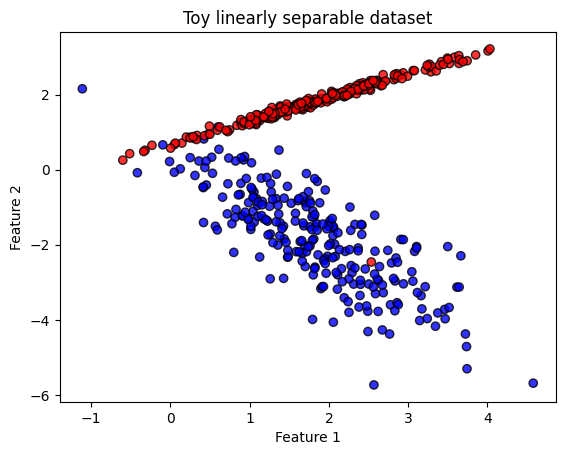

In [17]:
# TODO: Visualize the dataset using a scatter plot
# Color points by class label

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', alpha=0.8)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Toy linearly separable dataset')
plt.show()


## 2. Train–Test Split

Before any model training, we split the data.

Why?
- To evaluate generalization
- To avoid lying to ourselves

Standard split:
- 70% training
- 30% testing


In [18]:
# TODO: Split the dataset into training and testing sets
# Use test_size=0.3 and random_state=42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


## 3. Baseline Weak Learner (Decision Stump)

Before AdaBoost, we test **one weak learner alone**.

We intentionally restrict the model:
- max_depth = 1
- This is called a **decision stump**

Expectation:
- Accuracy will not be impressive
- That is the point


In [27]:
# TODO: Create a DecisionTreeClassifier with max_depth=1
# SVM, Logistic Regression
# This is our weak learner
base_learner = DecisionTreeClassifier(max_depth=1, random_state=42)
base_learner_svm = SVC(kernel='rbf', C=0.1, random_state=42)
base_learner_lr = LogisticRegression(max_iter=1000)


In [28]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
  model.fit(X_train, y_train)
  y_test_pred = model.predict(X_test)

  model_name = type(model).__name__
  print(f"Model: {model_name} Accuracy: ", accuracy_score(y_test, y_test_pred))
  return y_test_pred

In [29]:
# TODO: Train the weak learner
# TODO: Predict on test data
# TODO: Calculate and print accuracy
y_test_pred_bl = evaluate_model(base_learner, X_train, X_test, y_train, y_test)
y_test_pred_svm = evaluate_model(base_learner_svm, X_train, X_test, y_train, y_test)
y_test_pred_lr = evaluate_model(base_learner_lr, X_train, X_test, y_train, y_test)


Model: DecisionTreeClassifier Accuracy:  0.96
Model: SVC Accuracy:  0.984
Model: LogisticRegression Accuracy:  0.96



## 4. AdaBoost Classifier – Core Practice

Now we combine **many weak learners** using AdaBoost.

Key idea:
- Each learner focuses more on previous mistakes
- Misclassified samples get more attention
- Correctly classified samples slowly matter less


In [31]:
learners = [base_learner, base_learner_svm, base_learner_lr]
for learner in learners:
  model = AdaBoostClassifier(
      estimator = learner,
      n_estimators = 50,
      learning_rate = 1.0,
      random_state = 42
  )
  model.fit(X_train,y_train)
  print(f"Accuracy: {accuracy_score(y_test, model.predict(X_test))}")

Accuracy: 0.96
Accuracy: 0.496
Accuracy: 0.952


In [35]:
# TODO: Initialize AdaBoostClassifier
# Use:
# - base_estimator = decision stump
# - n_estimators = 50
# - learning_rate = 1.0

model = AdaBoostClassifier(
    estimator = base_learner,
    n_estimators = 50,
    learning_rate = 1.0,
    random_state = 42
)



Accuracy: 0.96


In [37]:
# TODO: Train AdaBoost on training data
# TODO: Predict on test data
# TODO: Evaluate accuracy
# TODO: Print classification report
model.fit(X_train,y_train)
y_test_predict = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_test_predict)}")
print(classification_report(y_test, y_test_predict))

Accuracy: 0.96
              precision    recall  f1-score   support

           0       0.94      0.98      0.96        63
           1       0.98      0.94      0.96        62

    accuracy                           0.96       125
   macro avg       0.96      0.96      0.96       125
weighted avg       0.96      0.96      0.96       125




## 5. Weak Learner vs AdaBoost Comparison

Now we compare:
- One weak learner
- Many weak learners working together

Expectation:
- AdaBoost should outperform a single stump
- If not, something is wrong


In [10]:
# TODO: Create a comparison table
# Columns:
# - Model
# - Accuracy


## 6. Effect of Number of Estimators

AdaBoost performance depends heavily on:
- Number of estimators

More is not always better.

Your job:
- Experiment
- Observe
- Plot


In [11]:
# TODO: Try different n_estimators values
# Example: [5, 10, 20, 50, 100]

# Store accuracy for each value

In [12]:
# TODO: Plot n_estimators vs accuracy
# Label axes clearly


## 7. Effect of Learning Rate

Learning rate controls **how aggressively** AdaBoost updates sample weights.

Intuition:
- High learning rate → fast but risky
- Low learning rate → slow but stable

You will verify this experimentally.


In [13]:
# TODO: Experiment with different learning_rate values
# Example: [0.01, 0.1, 0.5, 1.0]

In [14]:
# TODO: Plot learning_rate vs accuracy


## 8. Feature Importance in AdaBoost

AdaBoost can tell us:
- Which features were more influential

This depends on:
- How often a feature is used in splits
- How strong the corresponding learners were


In [15]:
# TODO: Extract feature importance from AdaBoost
# TODO: Plot feature importance


## 9. Reflection (Mandatory)

Answer in your own words.

1. Why is AdaBoost called *adaptive*?
2. What happens to misclassified samples after each iteration?
3. Why do we prefer weak learners instead of strong ones?
4. When should AdaBoost not be used?



## 10. Bonus Challenge (Optional)

Replace the decision stump with **Logistic Regression** as the base estimator.

Questions:
- Does AdaBoost still work?
- Should you do this in practice?
- Why or why not?


In [16]:
# TODO: Replace DecisionTreeClassifier with LogisticRegression or SVM
# Train AdaBoost again
# Compare performance